# Foundation ePSF head visualisation

Visual + quantitative check on the production PSF model. Section ordering
matters: **the Gaia rebuild preflight comes first** — if the build pipeline
is not selecting and centring real stars, every downstream PSF metric is
meaningless no matter how it is computed.

Sections:

1. Gaia rebuild preflight — per-band counts / SNR / source_id presence.
2. Sanity check — same source across all bands (is the build picking real
   isolated point sources?).
3. Load FoundationEPSFHead — checkpoint config, demo tile encoding,
   field-centre ePSFs.
4. Per-band predicted ePSF at field centre (log scale, core σ in title).
5. Radial profile per band.
6. Held-out validation — Pearson r and chi^2/dof per band.

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "io" else Path.cwd()
sys.path.insert(0, str(ROOT / "models"))

TRAIN_DIR = ROOT / "data/psf_training_gaia_pm"
ALL_BANDS = [
    "rubin_u", "rubin_g", "rubin_r", "rubin_i", "rubin_z", "rubin_y",
    "euclid_VIS", "euclid_Y", "euclid_J", "euclid_H",
]
PCA_BANDS = list(ALL_BANDS)
PCA_PX_NATIVE = {b: 0.2 if b.startswith("rubin") else 0.1 for b in ALL_BANDS}


## 1. Gaia rebuild preflight

Run these checks on a freshly rebuilt Gaia training set **before** retraining the PSF head.

What to verify:

1. All expected band files exist and carry `source_id`.
2. The same Gaia source looks consistently centred across `rubin_r/i/z` and `euclid_VIS/Y/J/H`.
3. The centroid residual summary is improved, especially in the higher-S/N bands.


TRAIN_DIR = /home/shemmati/Work/Projects/JAISP/data/psf_training_gaia_pm
band               n  snr_med  source_id
rubin_u          828     74.3       True
rubin_g          975   1684.6       True
rubin_r          975   2846.7       True
rubin_i          975   3238.5       True
rubin_z          975   2619.1       True
rubin_y          975    573.0       True
euclid_VIS      1151    560.6       True
euclid_Y        1119    220.0       True
euclid_J        1103    240.5       True
euclid_H        1107    236.3       True


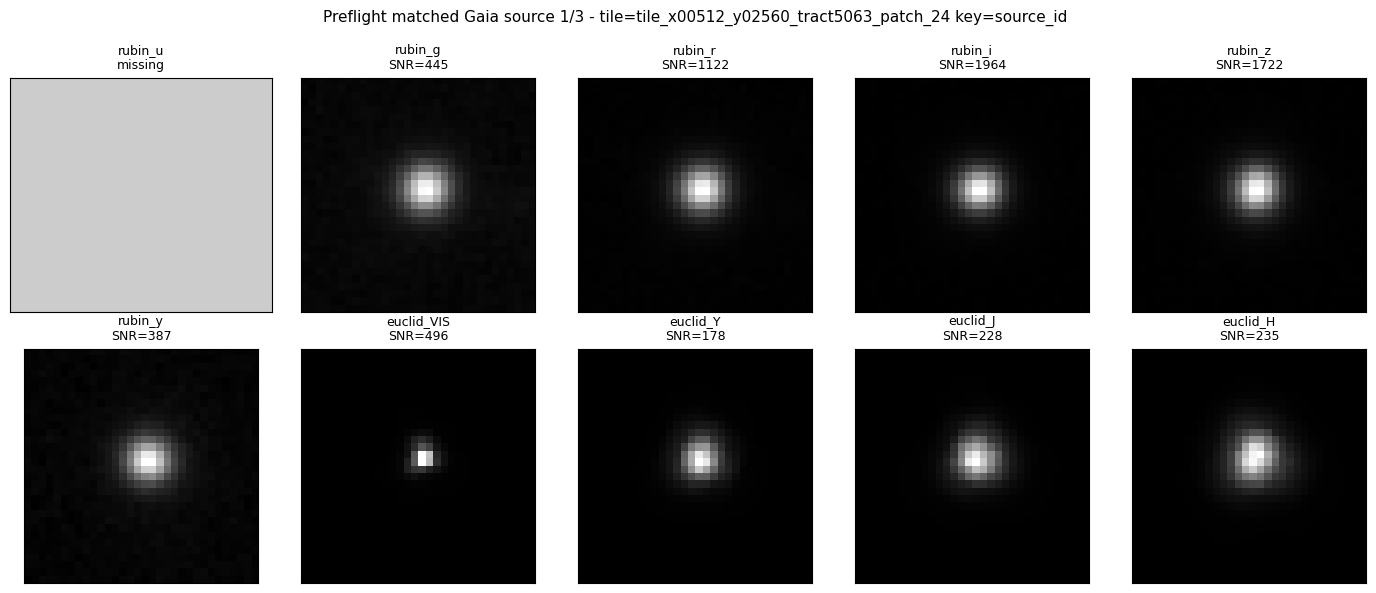

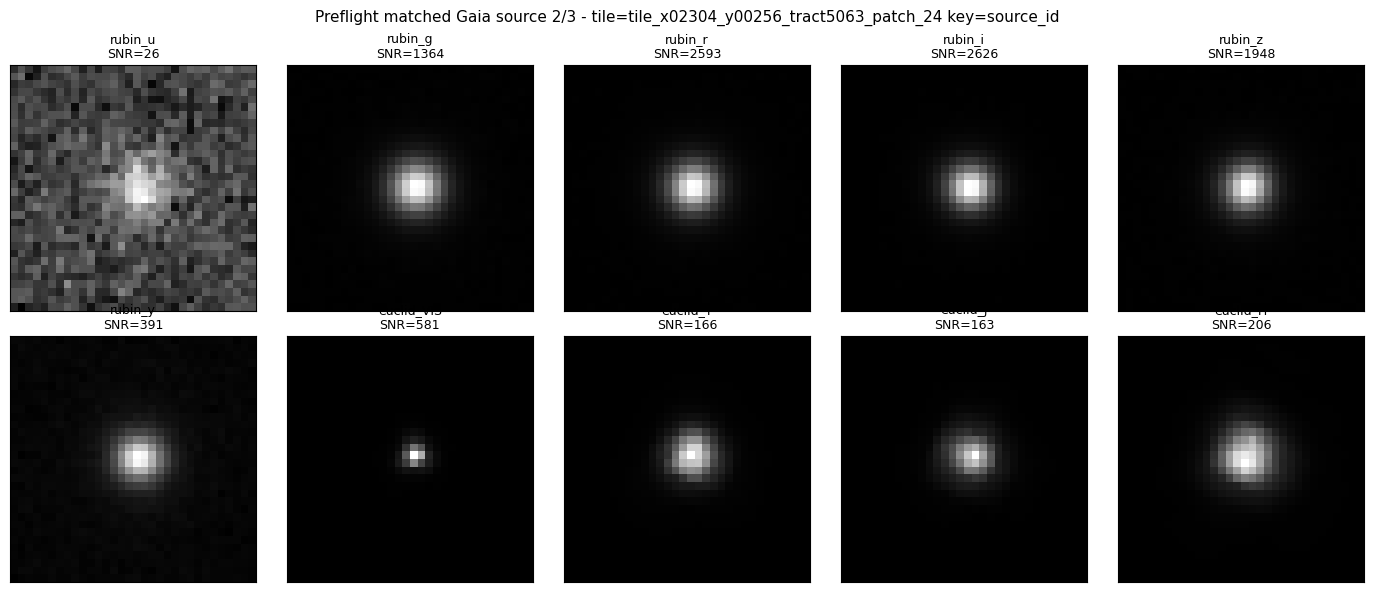

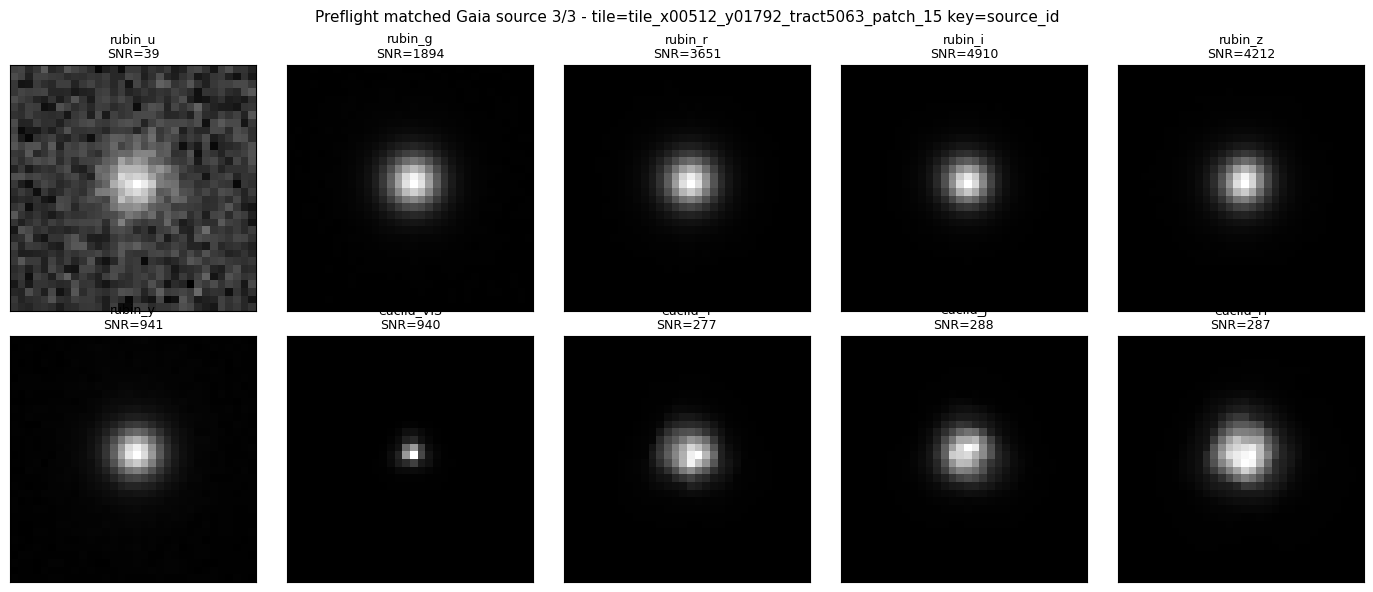


band        median_dx  median_dy   median_r
rubin_r        -0.009      0.015      0.032
rubin_i        -0.016      0.022      0.037
rubin_z        -0.006     -0.002      0.028


/tmp/ipykernel_2057767/3197972960.py:21: RuntimeWarning: All-NaN slice encountered
  bg = float(np.nanmedian(s[bg_mask])) if bg_mask.any() else float(np.nanmedian(s))


euclid_VIS     -0.016      0.056      0.076
euclid_Y        0.059      0.006      0.108
euclid_J        0.056      0.008      0.091
euclid_H        0.056      0.006      0.082


In [2]:
ANCHOR_BAND = "rubin_r"
N_PREFLIGHT = 3
SEED = 42

def _match_source(d, tile, key_name, key_value):
    tile_match = d["tile_id"] == tile
    if key_name in d.files:
        if key_name == "source_id":
            return tile_match & (d[key_name] == key_value)
        return tile_match & (np.abs(d[key_name] - float(key_value)) < 1e-3)
    return np.zeros(d["tile_id"].shape, dtype=bool)

def _centroid_residual(stamp, frac_xy, ap_radius=5.0):
    s = np.asarray(stamp, dtype=np.float64)
    S = s.shape[-1]
    yy, xx = np.indices(s.shape, dtype=np.float64)
    tx = S // 2 + float(frac_xy[0])
    ty = S // 2 + float(frac_xy[1])
    r = np.hypot(xx - tx, yy - ty)
    bg_mask = r > min(14.0, S * 0.38)
    bg = float(np.nanmedian(s[bg_mask])) if bg_mask.any() else float(np.nanmedian(s))
    w = np.clip(s - bg, 0.0, None) * (r < ap_radius)
    total = float(w.sum())
    if total <= 0:
        return np.nan, np.nan, np.nan
    cx = float((xx * w).sum() / total)
    cy = float((yy * w).sum() / total)
    dx = cx - tx
    dy = cy - ty
    return dx, dy, float(np.hypot(dx, dy))

band_data = {}
print(f"TRAIN_DIR = {TRAIN_DIR}")
print(f"{'band':12s} {'n':>7s} {'snr_med':>8s} {'source_id':>10s}")
for band in ALL_BANDS:
    p = TRAIN_DIR / f"{band}.npz"
    if not p.exists():
        band_data[band] = None
        print(f"{band:12s} {'missing':>7s} {'-':>8s} {'-':>10s}")
        continue
    d = np.load(p, allow_pickle=False)
    band_data[band] = d
    n = int(d['stamps'].shape[0])
    snr_med = float(np.nanmedian(d['snr'])) if n > 0 else float('nan')
    has_sid = 'source_id' in d.files
    print(f"{band:12s} {n:7d} {snr_med:8.1f} {str(has_sid):>10s}")

d_anchor = band_data[ANCHOR_BAND]
if d_anchor is None:
    raise FileNotFoundError(f"Missing anchor band file for {ANCHOR_BAND}: {TRAIN_DIR / (ANCHOR_BAND + '.npz')}")
match_key = 'source_id' if 'source_id' in d_anchor.files else 'g_mag'
rng = np.random.RandomState(SEED)
n_pick = min(N_PREFLIGHT, int(d_anchor['stamps'].shape[0]))
anchor_idx = rng.choice(d_anchor['stamps'].shape[0], n_pick, replace=False)

for trial, idx in enumerate(anchor_idx, start=1):
    tile = d_anchor['tile_id'][idx]
    key_value = d_anchor[match_key][idx]
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for ax, band in zip(axes.flat, ALL_BANDS):
        d = band_data.get(band)
        ax.set_xticks([])
        ax.set_yticks([])
        if d is None or match_key not in d.files:
            ax.set_facecolor('#cccccc')
            ax.set_title(f"{band}\nmissing", fontsize=9)
            continue
        m = _match_source(d, tile, match_key, key_value)
        if not m.any():
            ax.set_facecolor('#cccccc')
            ax.set_title(f"{band}\nmissing", fontsize=9)
            continue
        j = int(np.where(m)[0][0])
        s = d['stamps'][j]
        ax.imshow(s, origin='lower', cmap='gray')
        ax.set_title(f"{band}\nSNR={float(d['snr'][j]):.0f}", fontsize=9)
    fig.suptitle(f"Preflight matched Gaia source {trial}/{n_pick} - tile={tile} key={match_key}", fontsize=11)
    plt.tight_layout()
    plt.show()

print()
print(f"{'band':10s} {'median_dx':>10s} {'median_dy':>10s} {'median_r':>10s}")
for band in ['rubin_r', 'rubin_i', 'rubin_z', 'euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H']:
    d = band_data.get(band)
    if d is None:
        continue
    S = d['stamps'].shape[-1]
    dxs, dys = [], []
    n_eval = min(2000, int(d['stamps'].shape[0]))
    for stamp, frac in zip(d['stamps'][:n_eval], d['frac_xy'][:n_eval]):
        dx, dy, dr = _centroid_residual(stamp, frac)
        if np.isfinite(dr):
            dxs.append(dx)
            dys.append(dy)
    if not dxs:
        continue
    dxs = np.asarray(dxs)
    dys = np.asarray(dys)
    print(f"{band:10s} {np.median(dxs):10.3f} {np.median(dys):10.3f} {np.median(np.hypot(dxs, dys)):10.3f}")


## 2. Sanity check — same source across all bands (GAIA-anchored)

Stamps are now built from **GAIA DR3 stars** (sub-mas RA/Dec, confirmed point sources via parallax / proper motion / single-source flags) instead of CenterNet detections. Each band's WCS projects (RA, Dec) → pixel coords directly, eliminating the bogus VIS-to-Rubin half-pixel scaling that caused the previous off-centre stamps.

This cell picks 10 random GAIA-anchored sources (anchored on rubin_r) and shows the matched stamp in every band where the source has coverage.

**What to look for:** clean centred star-like cores in every panel. With GAIA you should see this — if you don't, the build pipeline still has a bug.

Empty grey panels = the source isn't in that band's npz (failed SNR cut, edge clip, or no coverage). SNR labelled in red.

Build:
```
PYTHONPATH=models python models/psf/build_psf_gaia_training_set.py \
    --rubin-dir   data/rubin_tiles_all \
    --euclid-dir  data/euclid_tiles_all \
    --out-dir     data/psf_training_gaia \
    --stamp-size  32
```


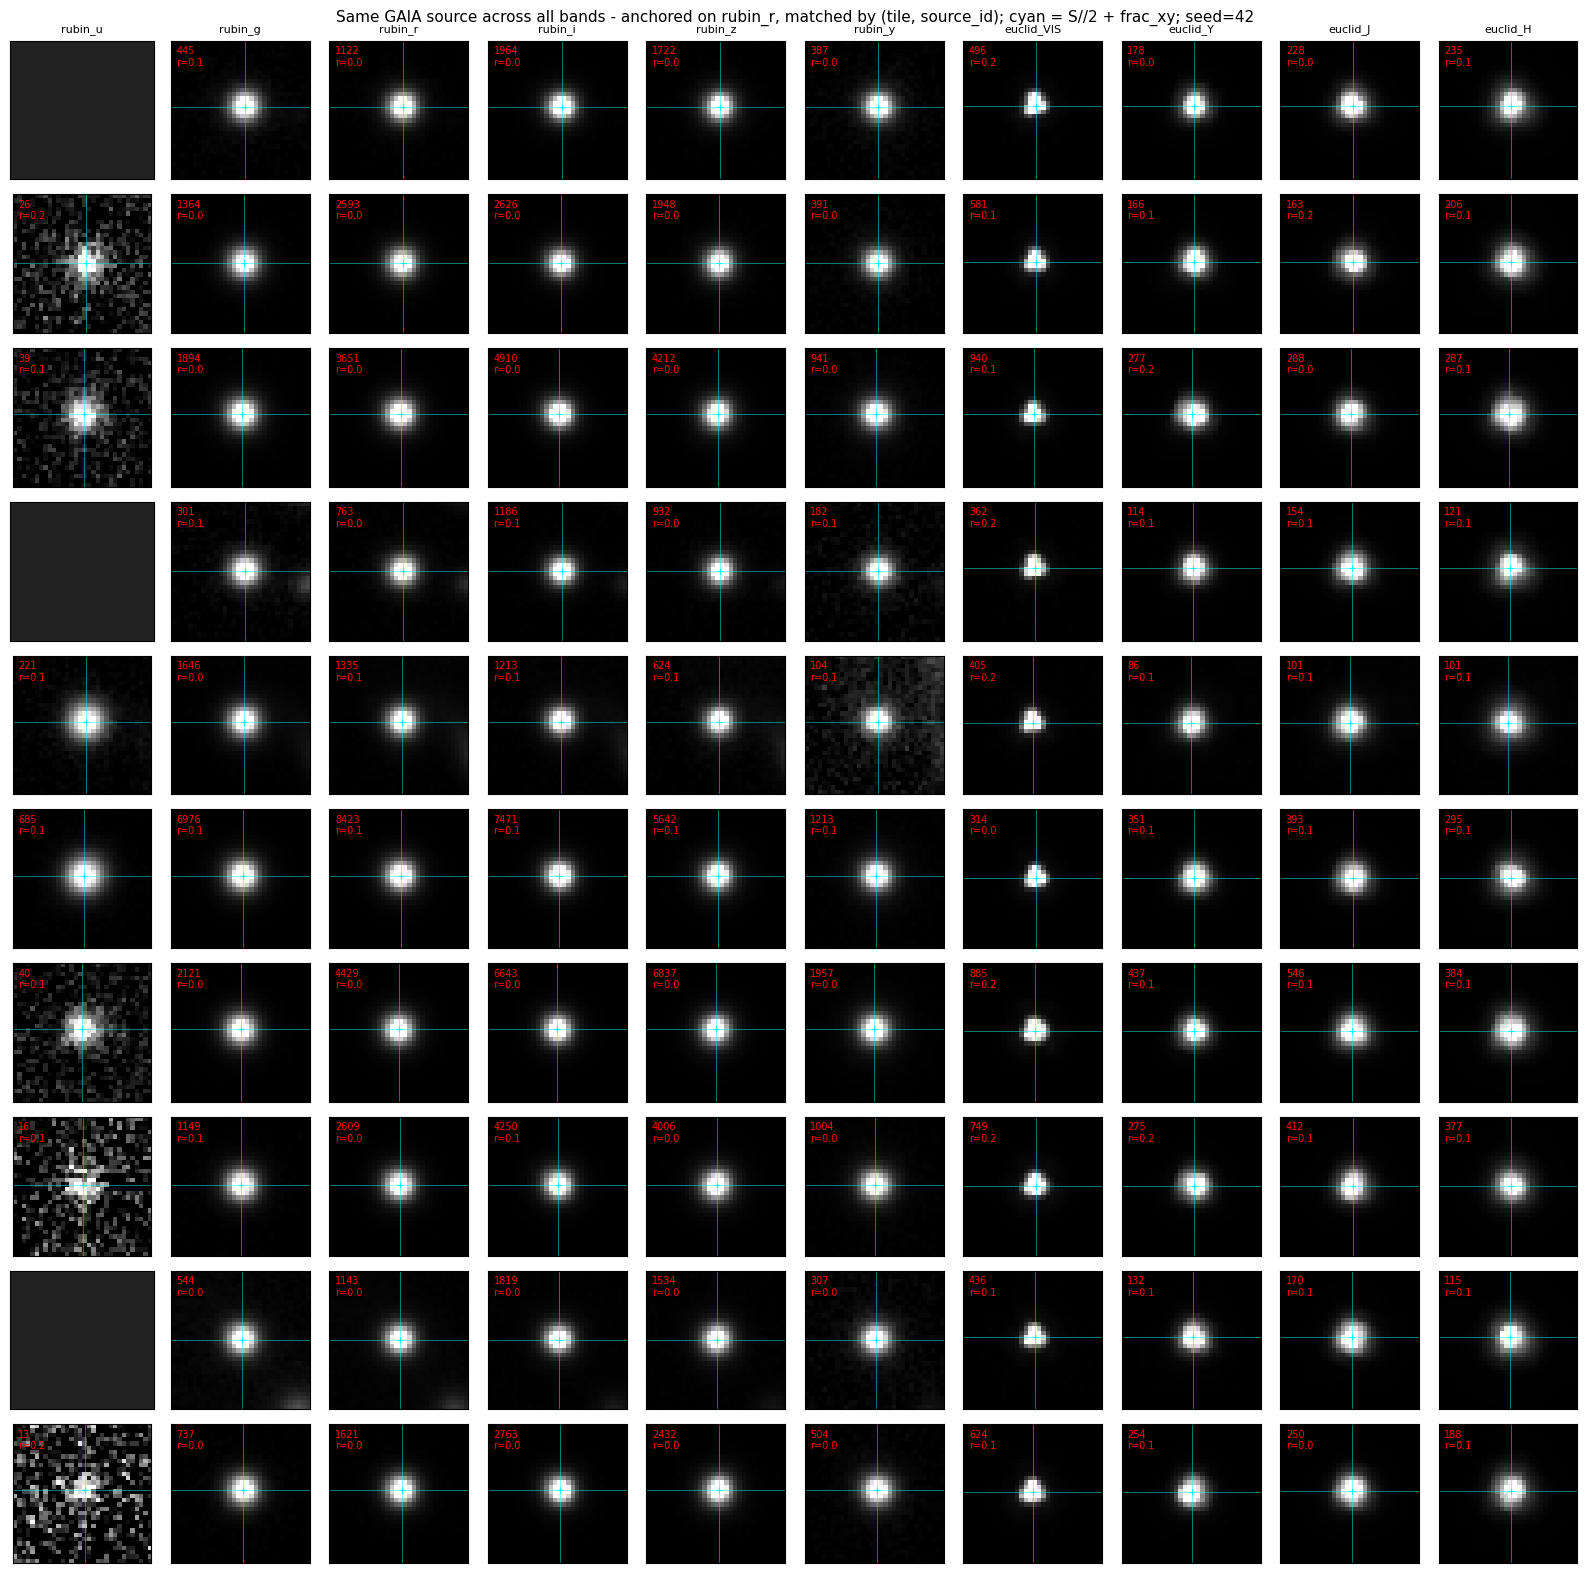

band             n median_r_px  p90_r_px  max_r_px
rubin_u          7       0.089     0.241     0.249
rubin_g         10       0.042     0.079     0.106
rubin_r         10       0.033     0.066     0.077
rubin_i         10       0.038     0.074     0.079
rubin_z         10       0.022     0.055     0.059
rubin_y         10       0.028     0.070     0.074
euclid_VIS      10       0.144     0.193     0.197
euclid_Y        10       0.101     0.152     0.171
euclid_J        10       0.089     0.145     0.219
euclid_H        10       0.087     0.134     0.139


In [3]:
ANCHOR_BAND = "rubin_r"
N_RANDOM = 10
SEED = 42

def _match_source(d, tile, key_name, key_value):
    tile_match = d["tile_id"] == tile
    if key_name in d.files:
        if key_name == "source_id":
            return tile_match & (d[key_name] == key_value)
        return tile_match & (np.abs(d[key_name] - float(key_value)) < 1e-3)
    return np.zeros(d["tile_id"].shape, dtype=bool)

def _centroid_residual(stamp, frac_xy, ap_radius=5.0):
    s = np.asarray(stamp, dtype=np.float64)
    S = s.shape[-1]
    yy, xx = np.indices(s.shape, dtype=np.float64)
    tx = S // 2 + float(frac_xy[0])
    ty = S // 2 + float(frac_xy[1])
    r = np.hypot(xx - tx, yy - ty)
    bg_mask = r > min(14.0, S * 0.38)
    bg = float(np.nanmedian(s[bg_mask])) if bg_mask.any() else float(np.nanmedian(s))
    w = np.clip(s - bg, 0.0, None) * (r < ap_radius)
    total = float(w.sum())
    if total <= 0:
        return np.nan, np.nan, np.nan
    cx = float((xx * w).sum() / total)
    cy = float((yy * w).sum() / total)
    dx = cx - tx
    dy = cy - ty
    return dx, dy, float(np.hypot(dx, dy))

d_anchor = np.load(TRAIN_DIR / f"{ANCHOR_BAND}.npz", allow_pickle=False)
match_key = "source_id" if "source_id" in d_anchor.files else "g_mag"
rng = np.random.RandomState(SEED)
anchor_idx = rng.choice(d_anchor["stamps"].shape[0], N_RANDOM, replace=False)
anchor_tiles = d_anchor["tile_id"][anchor_idx]
anchor_key_values = d_anchor[match_key][anchor_idx]

band_data = {}
for band in PCA_BANDS:
    p = TRAIN_DIR / f"{band}.npz"
    band_data[band] = np.load(p, allow_pickle=False) if p.exists() else None

resid_rows = []
fig, axes = plt.subplots(N_RANDOM, len(PCA_BANDS),
                         figsize=(len(PCA_BANDS) * 1.6, N_RANDOM * 1.6))
for row in range(N_RANDOM):
    tile = anchor_tiles[row]
    key_value = anchor_key_values[row]
    for col, band in enumerate(PCA_BANDS):
        ax = axes[row, col]
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(band, fontsize=8)
        d = band_data[band]
        if d is None or match_key not in d.files:
            ax.set_facecolor("#222"); continue
        m = _match_source(d, tile, match_key, key_value)
        if not m.any():
            ax.set_facecolor("#222"); continue
        idx = int(np.where(m)[0][0])
        s = d["stamps"][idx]
        frac = d["frac_xy"][idx]
        snr = float(d["snr"][idx])
        dx, dy, dr = _centroid_residual(s, frac)
        resid_rows.append((band, dr, dx, dy, snr))
        vmax = max(float(np.nanpercentile(s, 99)), 1e-6)
        ax.imshow(s, origin="lower", cmap="gray", vmin=0.0, vmax=vmax)
        S = s.shape[-1]
        tx = S // 2 + float(frac[0])
        ty = S // 2 + float(frac[1])
        ax.axhline(ty, color="cyan", alpha=0.55, lw=0.6)
        ax.axvline(tx, color="cyan", alpha=0.55, lw=0.6)
        ax.plot([tx], [ty], marker="+", ms=5, mew=0.8, color="cyan")
        ax.text(0.04, 0.96, f"{snr:.0f}\nr={dr:.1f}", color="red", fontsize=7,
                transform=ax.transAxes, va="top", ha="left",
                bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=1))
fig.suptitle(f"Same GAIA source across all bands - anchored on {ANCHOR_BAND}, matched by (tile, {match_key}); cyan = S//2 + frac_xy; seed={SEED}",
             fontsize=11)
plt.tight_layout(); plt.show()

print(f"{'band':14s} {'n':>3s} {'median_r_px':>11s} {'p90_r_px':>9s} {'max_r_px':>9s}")
for band in PCA_BANDS:
    vals = np.array([r for b, r, _dx, _dy, _snr in resid_rows if b == band and np.isfinite(r)])
    if vals.size == 0:
        print(f"{band:14s} {0:3d}")
        continue
    print(f"{band:14s} {vals.size:3d} {np.median(vals):11.3f} {np.percentile(vals, 90):9.3f} {np.max(vals):9.3f}")


## 3. Load FoundationEPSFHead

Loads the trained `FoundationEPSFHead` from the latest checkpoint, wraps the
foundation encoder (path read from the head checkpoint's saved config), and
encodes one tile so subsequent cells can query the head without re-encoding.

The head predicts `ePSF = per-band base ePSF + low-rank residual`, where the
residual coefficients are conditioned on frozen JAISP foundation features at
the source's VIS-frame position, the normalised tile position, and the band
id. Output is positive and unit-flux at every query point.

In [4]:
from matplotlib.colors import LogNorm

from load_foundation import load_foundation
from foundation_utils import FrozenEncoder, discover_tile_pairs, load_tile_data
from psf.foundation_epsf_head import (
    ALL_BANDS as HEAD_BANDS,
    RUBIN_BANDS as HEAD_RUBIN_BANDS,
    BAND_PIXEL_SCALE_ARCSEC,
    load_foundation_epsf_head,
)

HEAD_CKPT = ROOT / "models/checkpoints/foundation_epsf_head_gaia_gaussian_v10_pm/checkpoint_latest.pt"
RUBIN_DIR = ROOT / "data/rubin_tiles_all"
EUCLID_DIR = ROOT / "data/euclid_tiles_all"

def core_sigma_mas(psf_oversampled, oversampling, band, r_native=5.0):
    """Intensity-weighted core sigma (mas) inside r_native native pixels."""
    p = np.asarray(psf_oversampled, dtype=np.float64)
    P = p.shape[0]
    c = (P - 1) / 2.0
    yy, xx = np.indices(p.shape, dtype=np.float64)
    r_ovs = np.hypot(xx - c, yy - c)
    mask = r_ovs <= r_native * oversampling
    w = np.clip(p, 0.0, None) * mask
    tot = w.sum()
    if tot <= 0:
        return float("nan")
    sig2 = float((w * (r_ovs ** 2)).sum() / tot) / 2.0
    sigma_ovs = float(np.sqrt(max(sig2, 0.0)))
    return sigma_ovs * (BAND_PIXEL_SCALE_ARCSEC[band] / oversampling) * 1000.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_meta = torch.load(str(HEAD_CKPT), map_location="cpu", weights_only=False)
head = load_foundation_epsf_head(HEAD_CKPT, device=device)
head.eval()
foundation_ckpt = ROOT / ckpt_meta["config"]["foundation_checkpoint"]
foundation = load_foundation(str(foundation_ckpt), device=torch.device("cpu"), freeze=True)
frozen = FrozenEncoder(foundation).to(device).eval()
val_loss = ckpt_meta.get("val_metrics", {}).get("loss", float("nan"))
print(f"head: epoch={ckpt_meta.get('epoch')}  val_loss={val_loss:.4f}")
print(f"foundation: {foundation_ckpt.name}")
print(f"psf_size={head.psf_size}  oversampling={head.oversampling}")

PAIRS = discover_tile_pairs(str(RUBIN_DIR), str(EUCLID_DIR))
TILE_PATH = {tid: (rp, ep) for tid, rp, ep in PAIRS}

# Pre-encode one tile and store field-centre ePSFs for sections 4 and 5.
DEMO_TILE_ID, demo_rubin, demo_euclid = PAIRS[0]
print(f"demo tile: {DEMO_TILE_ID}")

with torch.no_grad():
    ctx_imgs, ctx_rms, _vis_hw, _wcs = load_tile_data(demo_rubin, demo_euclid, device)
    vis_img = ctx_imgs["euclid_VIS"]
    vis_rms = ctx_rms["euclid_VIS"]
    DEMO_BOTTLENECK = frozen.encoder(ctx_imgs, ctx_rms)["bottleneck"]
    DEMO_VIS_STEM = frozen.vis_stem(vis_img, vis_rms)
    DEMO_VIS_HW = (vis_img.shape[-2], vis_img.shape[-1])

    n_bands = len(HEAD_BANDS)
    pos_norm = torch.zeros(n_bands, 2, device=device)
    band_idx = torch.arange(n_bands, device=device)
    src_pos_vis = torch.tensor(
        [[DEMO_VIS_HW[1] * 0.5, DEMO_VIS_HW[0] * 0.5]] * n_bands,
        device=device, dtype=torch.float32,
    )
    out = head(
        pos_norm,
        band_idx,
        bottleneck=DEMO_BOTTLENECK,
        vis_stem_features=DEMO_VIS_STEM,
        source_positions_vis=src_pos_vis,
        fused_hw=(DEMO_BOTTLENECK.shape[-2], DEMO_BOTTLENECK.shape[-1]),
        vis_hw=DEMO_VIS_HW,
        return_dict=True,
    )
    EPSF_FIELD_CENTRE = out["epsf"][:, 0].detach().cpu().numpy()  # [B, P, P]

print()
print(f"{'band':12s} {'core σ (mas)':>14s}")
for band, p in zip(HEAD_BANDS, EPSF_FIELD_CENTRE):
    print(f"{band:12s} {core_sigma_mas(p, head.oversampling, band):>14.0f}")

EOFError: Ran out of input

## 4. Per-band predicted ePSF at field centre (log scale, core σ in title)

Predicted PSF per band at the demo tile's field centre. Log colormap (3
decades from peak) with the noise floor clipped. Title reports the
intensity-weighted core σ inside 5 native pixels.

Expected band σ (FWHM/2.35): Rubin ~300-400 mas, Euclid VIS ~70-150 mas,
Euclid Y/J/H ~170-200 mas.

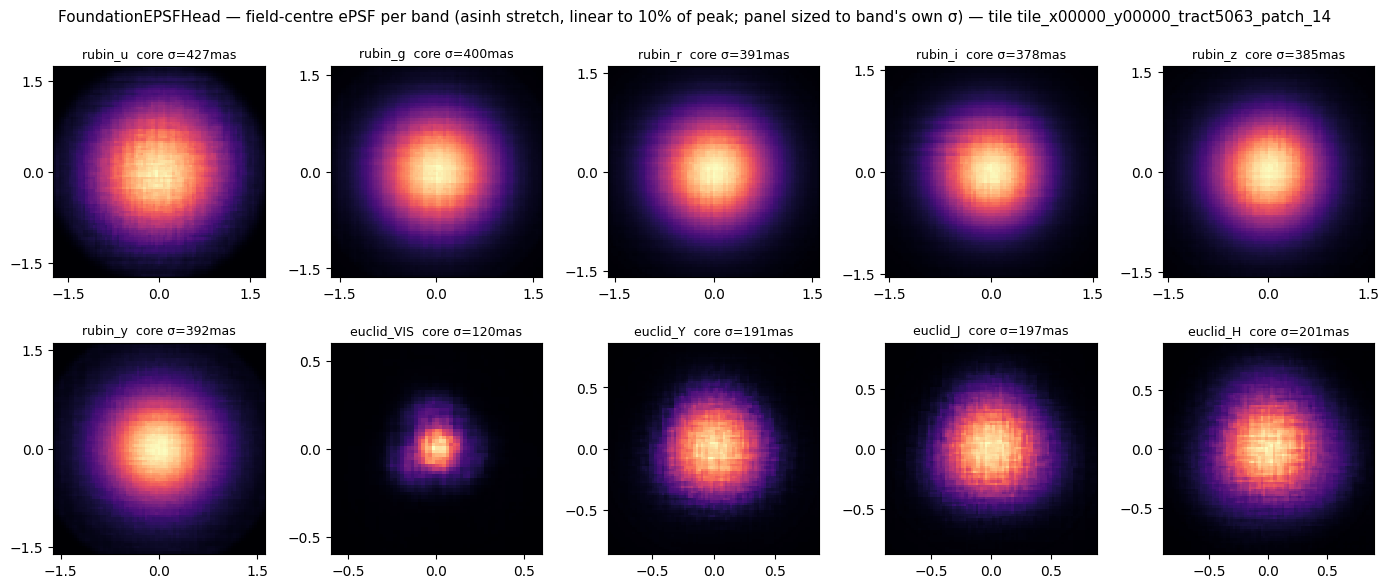

In [ ]:
# Asinh stretch (Lupton): linear near the peak, log-like in the wings,
# no noise-floor cliff. Visible bright disc sits at ~1-2 sigma rather than
# the 3.7 sigma cliff that LogNorm with a 1e-3 clip produces.
#
# Per-band display half-extent: still sized to each PSF's own ~3.7 sigma so
# all panels reveal a comparable amount of wing context.

NOISE_FLOOR_SIGMAS = 3.72
PANEL_MARGIN_ARCSEC = 0.15
MIN_DISPLAY_HALF = 0.6
ASINH_LINEAR_FRAC = 0.10  # asinh is linear down to this fraction of peak

from matplotlib.colors import AsinhNorm

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, band, p in zip(axes.flat, HEAD_BANDS, EPSF_FIELD_CENTRE):
    P = p.shape[0]
    px_over = BAND_PIXEL_SCALE_ARCSEC[band] / head.oversampling
    data_ext = (P - 1) / 2.0 * px_over
    pk = float(p.max())

    sig_mas = core_sigma_mas(p, head.oversampling, band)
    sigma_arcsec = sig_mas / 1000.0
    panel_half = NOISE_FLOOR_SIGMAS * sigma_arcsec + PANEL_MARGIN_ARCSEC
    panel_half = max(MIN_DISPLAY_HALF, min(panel_half, data_ext))

    ax.imshow(
        p,
        origin="lower",
        cmap="magma",
        extent=[-data_ext, data_ext, -data_ext, data_ext],
        norm=AsinhNorm(linear_width=pk * ASINH_LINEAR_FRAC, vmin=0.0, vmax=pk),
        interpolation="nearest",
    )
    ax.set_title(f"{band}  core σ={sig_mas:.0f}mas", fontsize=9)
    ax.set_xlim(-panel_half, panel_half)
    ax.set_ylim(-panel_half, panel_half)
    if panel_half >= 1.5:
        ticks = [-1.5, 0, 1.5]
    elif panel_half >= 1.0:
        ticks = [-1, 0, 1]
    elif panel_half >= 0.6:
        ticks = [-0.5, 0, 0.5]
    else:
        ticks = [-0.3, 0, 0.3]
    ax.set_xticks(ticks); ax.set_yticks(ticks)
fig.suptitle(
    f"FoundationEPSFHead — field-centre ePSF per band "
    f"(asinh stretch, linear to {ASINH_LINEAR_FRAC:.0%} of peak; panel sized to band's own σ) "
    f"— tile {DEMO_TILE_ID}",
    fontsize=11,
)
plt.tight_layout(); plt.show()

## 5. Radial profile per band

Azimuthal-mean radial profile (log-y) of the field-centre ePSFs from
section 4. Real PSFs fall off rapidly to a noise floor; flat or rising tails
at large r mean residual contamination.

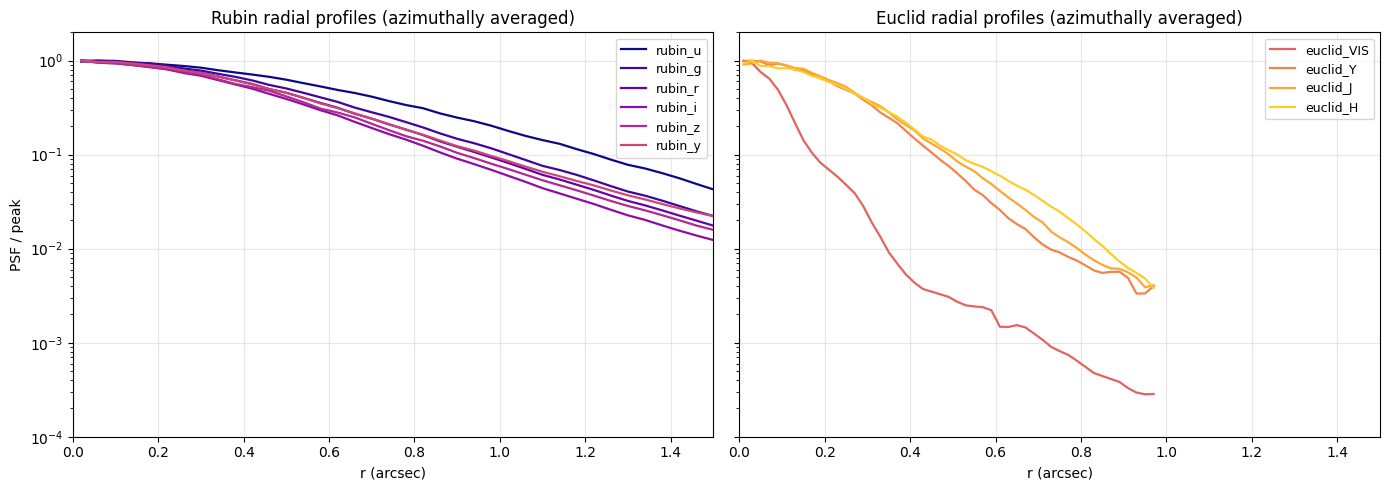

In [ ]:
def radial_profile(psf, n_bins=None):
    P = psf.shape[0]
    half = (P - 1) / 2.0
    if n_bins is None:
        n_bins = max(8, int(half))
    yy, xx = np.indices(psf.shape, dtype=np.float32)
    r = np.sqrt((xx - half) ** 2 + (yy - half) ** 2)
    edges = np.linspace(0, half, n_bins + 1)
    centres, profile = [], []
    for k in range(n_bins):
        m = (r >= edges[k]) & (r < edges[k + 1])
        if m.any():
            centres.append(0.5 * (edges[k] + edges[k + 1]))
            profile.append(float(psf[m].mean()))
    return np.array(centres), np.array(profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = plt.cm.plasma(np.linspace(0, 0.9, len(HEAD_BANDS)))
for bi, (band, psf) in enumerate(zip(HEAD_BANDS, EPSF_FIELD_CENTRE)):
    r_ovs, prof = radial_profile(psf)
    px_arcsec = BAND_PIXEL_SCALE_ARCSEC[band] / head.oversampling
    r_arcsec = r_ovs * px_arcsec
    prof_norm = prof / max(prof.max(), 1e-12)
    ax = axes[0 if band.startswith("rubin") else 1]
    ax.plot(r_arcsec, prof_norm, color=colors[bi], lw=1.6, label=band)
for ax, title in zip(axes, ["Rubin", "Euclid"]):
    ax.set_yscale("log")
    ax.set_xlim(0, 1.5)
    ax.set_ylim(1e-4, 2)
    ax.set_xlabel("r (arcsec)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_title(f"{title} radial profiles (azimuthally averaged)")
axes[0].set_ylabel("PSF / peak")
plt.tight_layout(); plt.show()

## 6. Held-out validation — shape match per band

Pearson r and chi^2/dof for the head rendered at the top-5 SNR Gaia stars per
band. Per band we collect the highest-SNR stamps across the training set,
group by tile id, encode each unique tile once, then query the head with each
star's `pos_norm` and VIS-frame source position. Pearson r is the meaningful
cross-band number (normalised, shape-only); chi^2/dof grows with stamp
brightness — compare across bands rather than to 1.

Encoding 28 unique tiles for held-out validation...


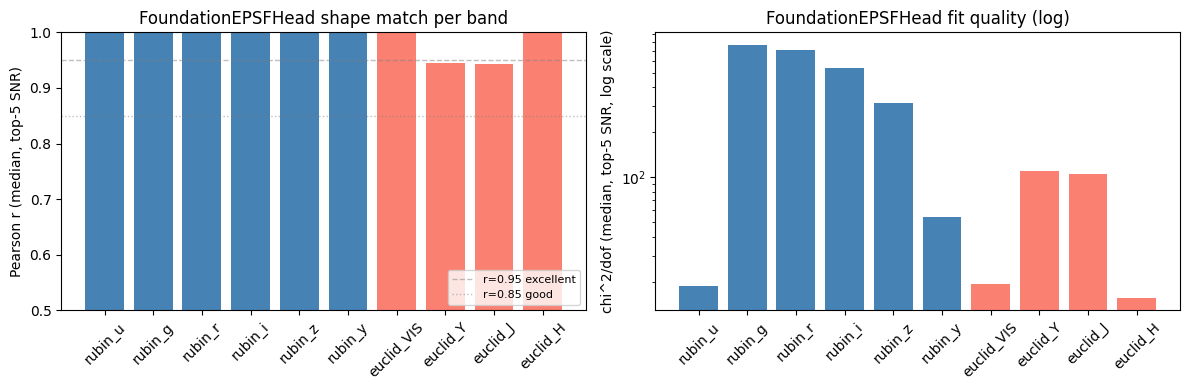


band            n_val        r     chi2/dof
rubin_u             5   1.000         18.7
rubin_g             5   1.000        764.9
rubin_r             5   1.000        711.6
rubin_i             5   1.000        537.5
rubin_z             5   1.000        313.2
rubin_y             5   1.000         53.9
euclid_VIS          5   0.998         19.5
euclid_Y            5   0.945        109.7
euclid_J            5   0.943        104.8
euclid_H            5   0.998         15.7


In [ ]:
def _chi2(pred, obs, rms):
    pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
    rms_fill = float(np.nanmedian(rms[np.isfinite(rms)])) if np.isfinite(rms).any() else 1.0
    rms = np.nan_to_num(rms, nan=rms_fill, posinf=rms_fill, neginf=rms_fill)
    inv_var = 1.0 / np.maximum(rms, 1e-6) ** 2
    return float(((pred - obs) ** 2 * inv_var).sum()) / max(int(obs.size - 1), 1)

def _pearson(a, b):
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0).ravel().astype(np.float64)
    b = np.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0).ravel().astype(np.float64)
    a = a - a.mean(); b = b - b.mean()
    den = np.sqrt((a*a).sum()) * np.sqrt((b*b).sum())
    return float((a*b).sum() / max(den, 1e-12))

def _fit_flux_bg(pred, obs, rms):
    pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
    rms_fill = float(np.nanmedian(rms[np.isfinite(rms)])) if np.isfinite(rms).any() else 1.0
    rms = np.nan_to_num(rms, nan=rms_fill, posinf=rms_fill, neginf=rms_fill)
    weight = 1.0 / np.maximum(rms, 1e-6) ** 2
    a = float((weight * pred * pred).sum())
    b = float((weight * pred).sum())
    c = float(weight.sum())
    d = float((weight * pred * obs).sum())
    e = float((weight * obs).sum())
    det = max(a * c - b * b, 1e-12)
    flux = max((d * c - b * e) / det, 0.0)
    bg = (a * e - b * d) / det
    return flux * pred + bg

VALIDATION_DIR = TRAIN_DIR
TOP_K = 5

records_by_tile = {}
for bi, band in enumerate(HEAD_BANDS):
    p = VALIDATION_DIR / f"{band}.npz"
    if not p.exists():
        continue
    d = np.load(p, allow_pickle=False)
    finite_stamp = np.isfinite(d['stamps']).mean(axis=(1, 2)) > 0.95
    finite_rms = np.isfinite(d['rms']).mean(axis=(1, 2)) > 0.95
    valid = np.isfinite(d['snr']) & finite_stamp & finite_rms
    valid_idx = np.where(valid)[0]
    if valid_idx.size == 0:
        continue
    n_pick = min(TOP_K, valid_idx.size)
    order = valid_idx[np.argsort(d['snr'][valid_idx])[::-1][:n_pick]]
    for k in order:
        tile = str(d['tile_id'][k])
        if tile not in TILE_PATH:
            continue
        records_by_tile.setdefault(tile, []).append({
            'band': band, 'band_idx': bi,
            'stamp': d['stamps'][k].astype(np.float32),
            'rms': d['rms'][k].astype(np.float32),
            'frac_xy': d['frac_xy'][k].astype(np.float32),
            'pos_norm': d['pos_norm'][k].astype(np.float32),
            'pos_pix': d['pos_pix'][k].astype(np.float32),
            'snr': float(d['snr'][k]),
        })

per_band = {b: [] for b in HEAD_BANDS}
n_rubin_bands = len(HEAD_RUBIN_BANDS)
print(f"Encoding {len(records_by_tile)} unique tiles for held-out validation...")
for tile_id, recs in records_by_tile.items():
    rubin_path, euclid_path = TILE_PATH[tile_id]
    with torch.no_grad():
        ctx_imgs, ctx_rms, _, _ = load_tile_data(rubin_path, euclid_path, device)
        vis_img = ctx_imgs['euclid_VIS']; vis_rms = ctx_rms['euclid_VIS']
        bn = frozen.encoder(ctx_imgs, ctx_rms)['bottleneck']
        stem = frozen.vis_stem(vis_img, vis_rms)
        H, W = vis_img.shape[-2:]
        pos_norm = torch.tensor(np.stack([r['pos_norm'] for r in recs]), device=device)
        band_idx = torch.tensor([r['band_idx'] for r in recs], device=device, dtype=torch.long)
        frac_xy = torch.tensor(np.stack([r['frac_xy'] for r in recs]), device=device)
        pos_pix = np.stack([r['pos_pix'] for r in recs]).astype(np.float32)
        rubin_mask = band_idx.cpu().numpy() < n_rubin_bands
        src_pos_vis = pos_pix.copy()
        src_pos_vis[rubin_mask] *= 2.0  # Rubin (0.2"/px) -> VIS (0.1"/px)
        src_pos_vis_t = torch.tensor(src_pos_vis, device=device)
        out = head(
            pos_norm, band_idx,
            bottleneck=bn, vis_stem_features=stem,
            source_positions_vis=src_pos_vis_t,
            fused_hw=(bn.shape[-2], bn.shape[-1]), vis_hw=(H, W),
            return_dict=True,
        )
        stamp_size = recs[0]['stamp'].shape[-1]
        native = head.render_at_native(out['epsf'], frac_xy, stamp_size=stamp_size)
        pred = native.squeeze(1).cpu().numpy()

    for r, p_pred in zip(recs, pred):
        scaled = _fit_flux_bg(p_pred, r['stamp'], r['rms'])
        per_band[r['band']].append((_pearson(scaled, r['stamp']), _chi2(scaled, r['stamp'], r['rms'])))

results = {b: (float(np.median([x[1] for x in v])),
                float(np.median([x[0] for x in v])),
                len(v))
            for b, v in per_band.items() if v}
bands_ok  = list(results.keys())
chi2_vals = [results[b][0] for b in bands_ok]
r_vals    = [results[b][1] for b in bands_ok]
colors_   = ['steelblue' if b.startswith('rubin') else 'salmon' for b in bands_ok]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(bands_ok, r_vals, color=colors_)
axes[0].set_ylabel('Pearson r (median, top-5 SNR)')
axes[0].set_title('FoundationEPSFHead shape match per band')
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(0.95, color='gray', ls='--', lw=1, alpha=0.5, label='r=0.95 excellent')
axes[0].axhline(0.85, color='gray', ls=':',  lw=1, alpha=0.5, label='r=0.85 good')
axes[0].legend(fontsize=8, loc='lower right')
axes[1].bar(bands_ok, chi2_vals, color=colors_)
axes[1].set_yscale('log')
axes[1].set_ylabel('chi^2/dof (median, top-5 SNR, log scale)')
axes[1].set_title('FoundationEPSFHead fit quality (log)')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print()
print(f"{'band':14s} {'n_val':>6s}   {'r':>6s}   {'chi2/dof':>10s}")
for band in bands_ok:
    chi2_v, r_v, n_pick = results[band]
    print(f'{band:14s} {n_pick:6d}   {r_v:.3f}   {chi2_v:>10.1f}')